<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️🔍TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela, Casasola Hernán, Biazutti Luciano, Lera Anibal Ivan, Alvarado Marcelo



# 1. Comprensión del negocio

## 1.1 Contexto

Las redes informáticas son blanco constante de ataques como denegación de servicio (DoS), escaneo de puertos o infiltraciones. Detectarlos a tiempo es crítico para proteger la infraestructura, y hacerlo manualmente es inviable a escala. Para resolver este problema usamos el dataset **CIC-IDS-2017**, desarrollado por el Canadian Institute for Cybersecurity. Contiene **2,8 millones de flujos de red** capturados durante 5 días en un entorno controlado, etiquetados como tráfico normal y ataques como Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack e Infiltración.

**Fuentes**: [UNB - CIC-IDS-2017](https://www.unb.ca/cic/datasets/ids-2017.html)
[kaggle](https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset)

## 1.2 Definición del Problema

**Problema**: Clasificar tráfico de red como benigno vs malicioso y por tipo de ataque.

**Tipo de problema**: Clasificación supervisada multiclase.

**Objetivo**: Detectar intrusiones con alta precisión y recall.


## 1.3 Fichas del proyecto

[📋 Información del dataset](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/ficha_del_proyecto.md)

[📖 Diccionario de Datos](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/diccionario_de_datos.md)

[🛡️ Diccionario de Clases y Tipos de Ataques](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/clase_label.md)

## 1.4 ⚠️ Problemas conocidos del dataset

* **Tamaño del archivo**: 2,8M de filas puede ser lento en máquinas locales. Nosotros vamos a trabajar con archivos .parquet ya que optimiza el almacenamiento mediante una estructura columnar que maximiza la compresión y acelera las consultas al leer solo los datos necesarios.

* **Valores infinitos**: las features Flow Bytes/s y Flow Packets/s contienen np.inf. Convertirlos a NaN y decidir si eliminamos esas filas o imputarles un valor promedio.

* **Desbalance severo de clases**: BENIGN representa ~80% de los registros. Requiere estrategia de balanceo.

# 2. Comprensión de los datos

## 2.1 Lectura del dataset

In [1]:
# Librerias
import os
import glob
import json
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Definición de colores para gráficos
COLOR_BENIGNO = '#A1D99B'  # Verde pastel
COLOR_ATAQUE  = '#F8766D'  # Rojo pastel
COLOR_NEUTRO  = '#AED6F1'  # Azul pastel

In [2]:
# Montar en Drive
from google.colab import drive
drive.mount('/content/drive')

# Rutas principales
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Dataset'
CHECKPOINT_DIR = '/content/drive/MyDrive/Colab Notebooks/Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'Dataset en: {DATA_DIR}')
print(f'Checkpoints en: {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset en: /content/drive/MyDrive/Colab Notebooks/Dataset
Checkpoints en: /content/drive/MyDrive/Colab Notebooks/Checkpoints


In [ ]:
# Cargar checkpoint sección 3
ruta_ckpt_s3 = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'

CHECKPOINT_CARGADO = False   # bandera de control

if os.path.exists(ruta_ckpt_s3):
    df = pd.read_parquet(ruta_ckpt_s3)
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    CHECKPOINT_CARGADO = True
    print('Checkpoint de sección 3 cargado.')
    print(f' Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}')
    print('  Podés saltar hasta la Sección 4.')
else:
    print('No se encontró checkpoint. Continuá con la carga del dataset.')

Mounted at /content/drive
Dataset en: /content/drive/MyDrive/Colab Notebooks/Dataset
Checkpoints en: /content/drive/MyDrive/Colab Notebooks/Checkpoints


In [3]:
# Carga del Dataset (saltar si cargaste checkpoint)

# Buscar todos los archivos .parquet en esa carpeta automáticamente
parquet_files = glob.glob(os.path.join(DATA_DIR, '*.parquet'))

# Unir todos los archivos en uno solo
dfs_list = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    dfs_list.append(df_temp)

df = pd.concat(dfs_list, ignore_index=True)

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip()

print(f'Dataset cargado con {df.shape[0]:,} filas y con {df.shape[1]} columnas.')

Dataset cargado con 2,830,743 filas y con 79 columnas.


In [ ]:
# Vista rápida de las primeras filas
pd.set_option('display.max_rows', None)
df.head().round(2)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [8]:
# Tipos de variables
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print('Numéricas:', len(num_cols))
print('Categóricas:', cat_cols)

Numéricas: 78
Categóricas: Index(['Label'], dtype='object')


**Respuestas**

**¿Cuántas filas y columnas hay?** El dataset contiene 2.830.743 filas y 79 columnas.

**¿Qué tipos de datos aparecen?** Predominan variables numéricas (78) y una variable categórica (Label).

**¿Qué representa cada fila?**
Cada fila es un *flujo de red* (conjunto de paquetes entre dos extremos en un tiempo determinado), capturado y etiquetado como benigno o como un tipo de ataque específico.

## 2.2 Identificación de la variable objetivo

In [6]:
# Tabla resumen de clases
resumen_clases = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': pcts.round(2),
    'Tipo': ['Benigno' if c == 'BENIGN' else 'Ataque' for c in counts.index]
})
print(resumen_clases.to_string())

                            Cantidad  Porcentaje (%)     Tipo
Label                                                        
BENIGN                       2273097           80.30  Benigno
DoS Hulk                      231073            8.16   Ataque
PortScan                      158930            5.61   Ataque
DDoS                          128027            4.52   Ataque
DoS GoldenEye                  10293            0.36   Ataque
FTP-Patator                     7938            0.28   Ataque
SSH-Patator                     5897            0.21   Ataque
DoS slowloris                   5796            0.20   Ataque
DoS Slowhttptest                5499            0.19   Ataque
Bot                             1966            0.07   Ataque
Web Attack � Brute Force        1507            0.05   Ataque
Web Attack � XSS                 652            0.02   Ataque
Infiltration                      36            0.00   Ataque
Web Attack � Sql Injection        21            0.00   Ataque
Heartble

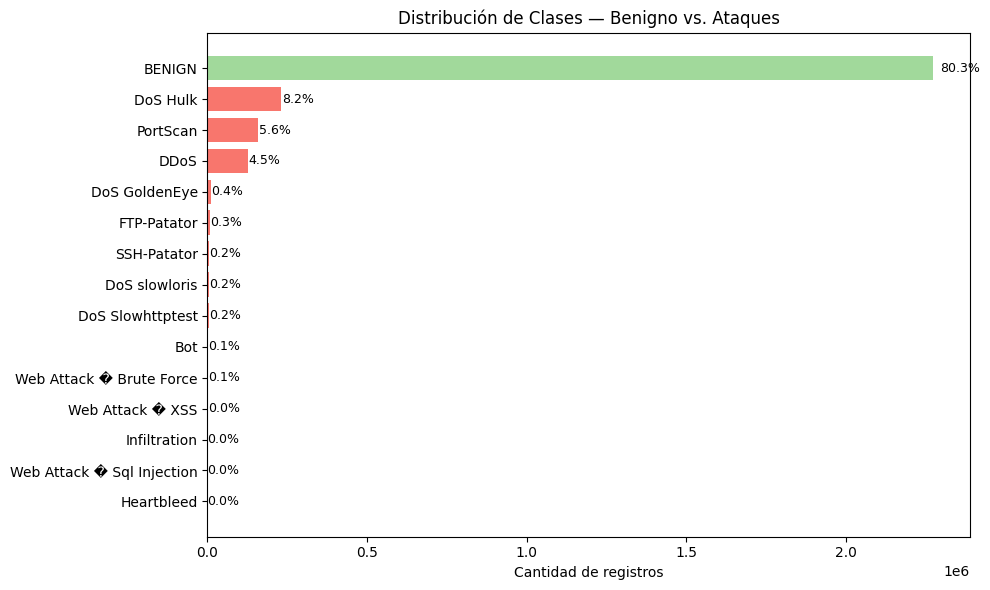

In [4]:
# Distribución de clases
counts = df['Label'].value_counts()
pcts   = counts / counts.sum() * 100

# Asignar color según si es benigno o ataque
colors = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, counts.values, color=colors)

# Etiqueta con porcentaje al final de cada barra
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Cantidad de registros')
ax.set_title('Distribución de Clases — Benigno vs. Ataques')
ax.invert_yaxis()   # la clase más frecuente arriba
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Cuál es la variable objetivo?**
La variable objetivo es Label, que indica si el tráfico es benigno o un tipo especícico de ataque.

**¿Hay múltiples clases?**
Sí, es un problema multiclase, incluye beningn más 14 tipos de ataques distintos.

**¿Está balanceado el dataset?**
El dataset está desbalanceado, ya que la clase BENIGN representa el 80% de los datos.

**¿Qué ataques dominan?**
Los 3 ataques más frecuentes son: DoS Hulk, PortScan y DDoS. Mientras que Heartbleed, Web Attack-Sql Injection	o Infiltration son extremadamente raros.


## 2.3 Estadísticas descriptivas

### 2.3.1 Estadísticos completos: media, std, min, cuartiles, max

In [9]:
# Desactivar notación científica y mostrar números normales
pd.set_option('display.float_format', '{:.2f}'.format)

# Calcular estadísticos base
desc = df[num_cols].describe().T

# Métricas adicionales útiles para el EDA
desc['mediana']   = df[num_cols].median()
desc['sesgo']     = df[num_cols].skew()        # >1 ó <-1 → distribución muy asimétrica
desc['curtosis']  = df[num_cols].kurtosis()    # >3 → muchos valores extremos
desc['%_ceros']   = (df[num_cols] == 0).mean() * 100
desc['%_nan']     = df[num_cols].isnull().mean() * 100

# Ordenar por sesgo (las más problemáticas primero)
desc_sorted = desc.sort_values('sesgo', ascending=False)

print(desc_sorted[['count', 'mean', 'mediana', 'std', 'min',
                    '25%', '75%', 'max', 'sesgo', 'curtosis',
                    '%_ceros', '%_nan']].to_string())

                                 count        mean  mediana         std             min    25%        75%          max    sesgo   curtosis  %_ceros  %_nan
Total Length of Fwd Packets 2830743.00      549.30    62.00     9993.59            0.00  12.00     187.00  12900000.00   805.57  988552.62    15.87   0.00
Subflow Fwd Bytes           2830743.00      549.29    62.00     9980.07            0.00  12.00     187.00  12870338.00   803.60  984882.53    15.87   0.00
act_data_pkt_fwd            2830743.00        5.42     1.00      636.43            0.00   0.00       2.00    213557.00   284.60   83076.67    34.02   0.00
Total Backward Packets      2830743.00       10.39     2.00      997.39            0.00   1.00       4.00    291922.00   244.68   62017.98    16.02   0.00
Subflow Bwd Packets         2830743.00       10.39     2.00      997.39            0.00   1.00       4.00    291922.00   244.68   62017.98    16.02   0.00
Subflow Fwd Packets         2830743.00        9.36     2.00      749.6

In [10]:
# Guardar la tabla descriptiva
desc_sorted.to_csv(f'{CHECKPOINT_DIR}/estadisticos_descriptivos.csv')
print('Tabla guardada en: Checkpoints/estadisticos_descriptivos.csv')

Tabla guardada en: Checkpoints/estadisticos_descriptivos.csv


### 2.3.2 Detección y Tratamiento de Valores infinitos

In [ ]:
# Ver valores infinitos por columna
inf_por_columna = np.isinf(df[num_cols]).sum()
print(inf_por_columna[inf_por_columna > 0])

Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [ ]:
#Reemplazar loa valores infinitos por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

### 2.3.3 Valores faltantes (NaN)

In [ ]:
# Valores faltantes (solo los que son > 0)
df.isnull().sum()[df.isnull().sum() > 0]

,0
Flow Bytes/s,2867
Flow Packets/s,2867


In [ ]:
# Alicar descisión
filas_antes = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
filas_despues = len(df)
print(f'Filas eliminadas: {filas_antes - filas_despues:,}')
print(f'Dataset final: {filas_despues:,} filas')

# Verificación
nan_total_final = df.isnull().sum().sum()
print(f'NaN restantes: {nan_total_final}')


Filas eliminadas: 2,867
Dataset final: 2,827,876 filas
NaN restantes: 0


**Respuestas**

**¿Cómo se distribuyen las variables?**
Las variables presentan alta dispersión, distribuciones sesgadas (no normales) y valores extremos en varias columnas.

**¿Hay valores raros?**
Sí, existen valores infinitos (np.inf) en variables como: Flow Bytes/s y Flow Packets/s.
Estos deben tratarse antes de modelar.


**¿Hay valores faltantes?** Sí, existen valores faltantes de la variable Flow Bytes/s y Flow Packets/s.

**¿Eliminamos o Imputamos estos valores faltantes?** Tenemos 5,734 valores de NaN, solo son 2867 filas (0.1% del dataset), al eliminarlas no sesgamos el entrenamiento.



### 2.3.4 Análisis de Outliers

In [ ]:
# Análisis de outliers
Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contar outliers por columna
outliers_count = (
    (df[num_cols] < limite_inferior) | (df[num_cols] > limite_superior)
).sum()

outliers_pct = (outliers_count / len(df) * 100).round(2)

outliers_df = pd.DataFrame({
    'n_outliers': outliers_count,
    'pct_outliers': outliers_pct
}).sort_values('pct_outliers', ascending=False)

# Top 20
print(outliers_df.head(20).to_string())
print(f'Features con > 10% de outliers: {(outliers_pct > 10).sum()}')
print(f'Features con > 20% de outliers: {(outliers_pct > 20).sum()}')

                             n_outliers  pct_outliers
Fwd IAT Mean                     670680         23.72
Fwd IAT Max                      665495         23.53
Fwd IAT Total                    665187         23.52
Fwd Packet Length Max            664211         23.49
Fwd Packet Length Std            663957         23.48
Fwd IAT Std                      659997         23.34
Bwd Packet Length Std            653968         23.13
Packet Length Variance           654086         23.13
Bwd Packet Length Max            637019         22.53
Destination Port                 625966         22.14
Max Packet Length                623427         22.05
Subflow Bwd Bytes                619005         21.89
Total Length of Bwd Packets      619005         21.89
Bwd IAT Std                      598847         21.18
Flow IAT Std                     598096         21.15
Flow IAT Mean                    572650         20.25
Bwd IAT Max                      567858         20.08
Idle Max                    

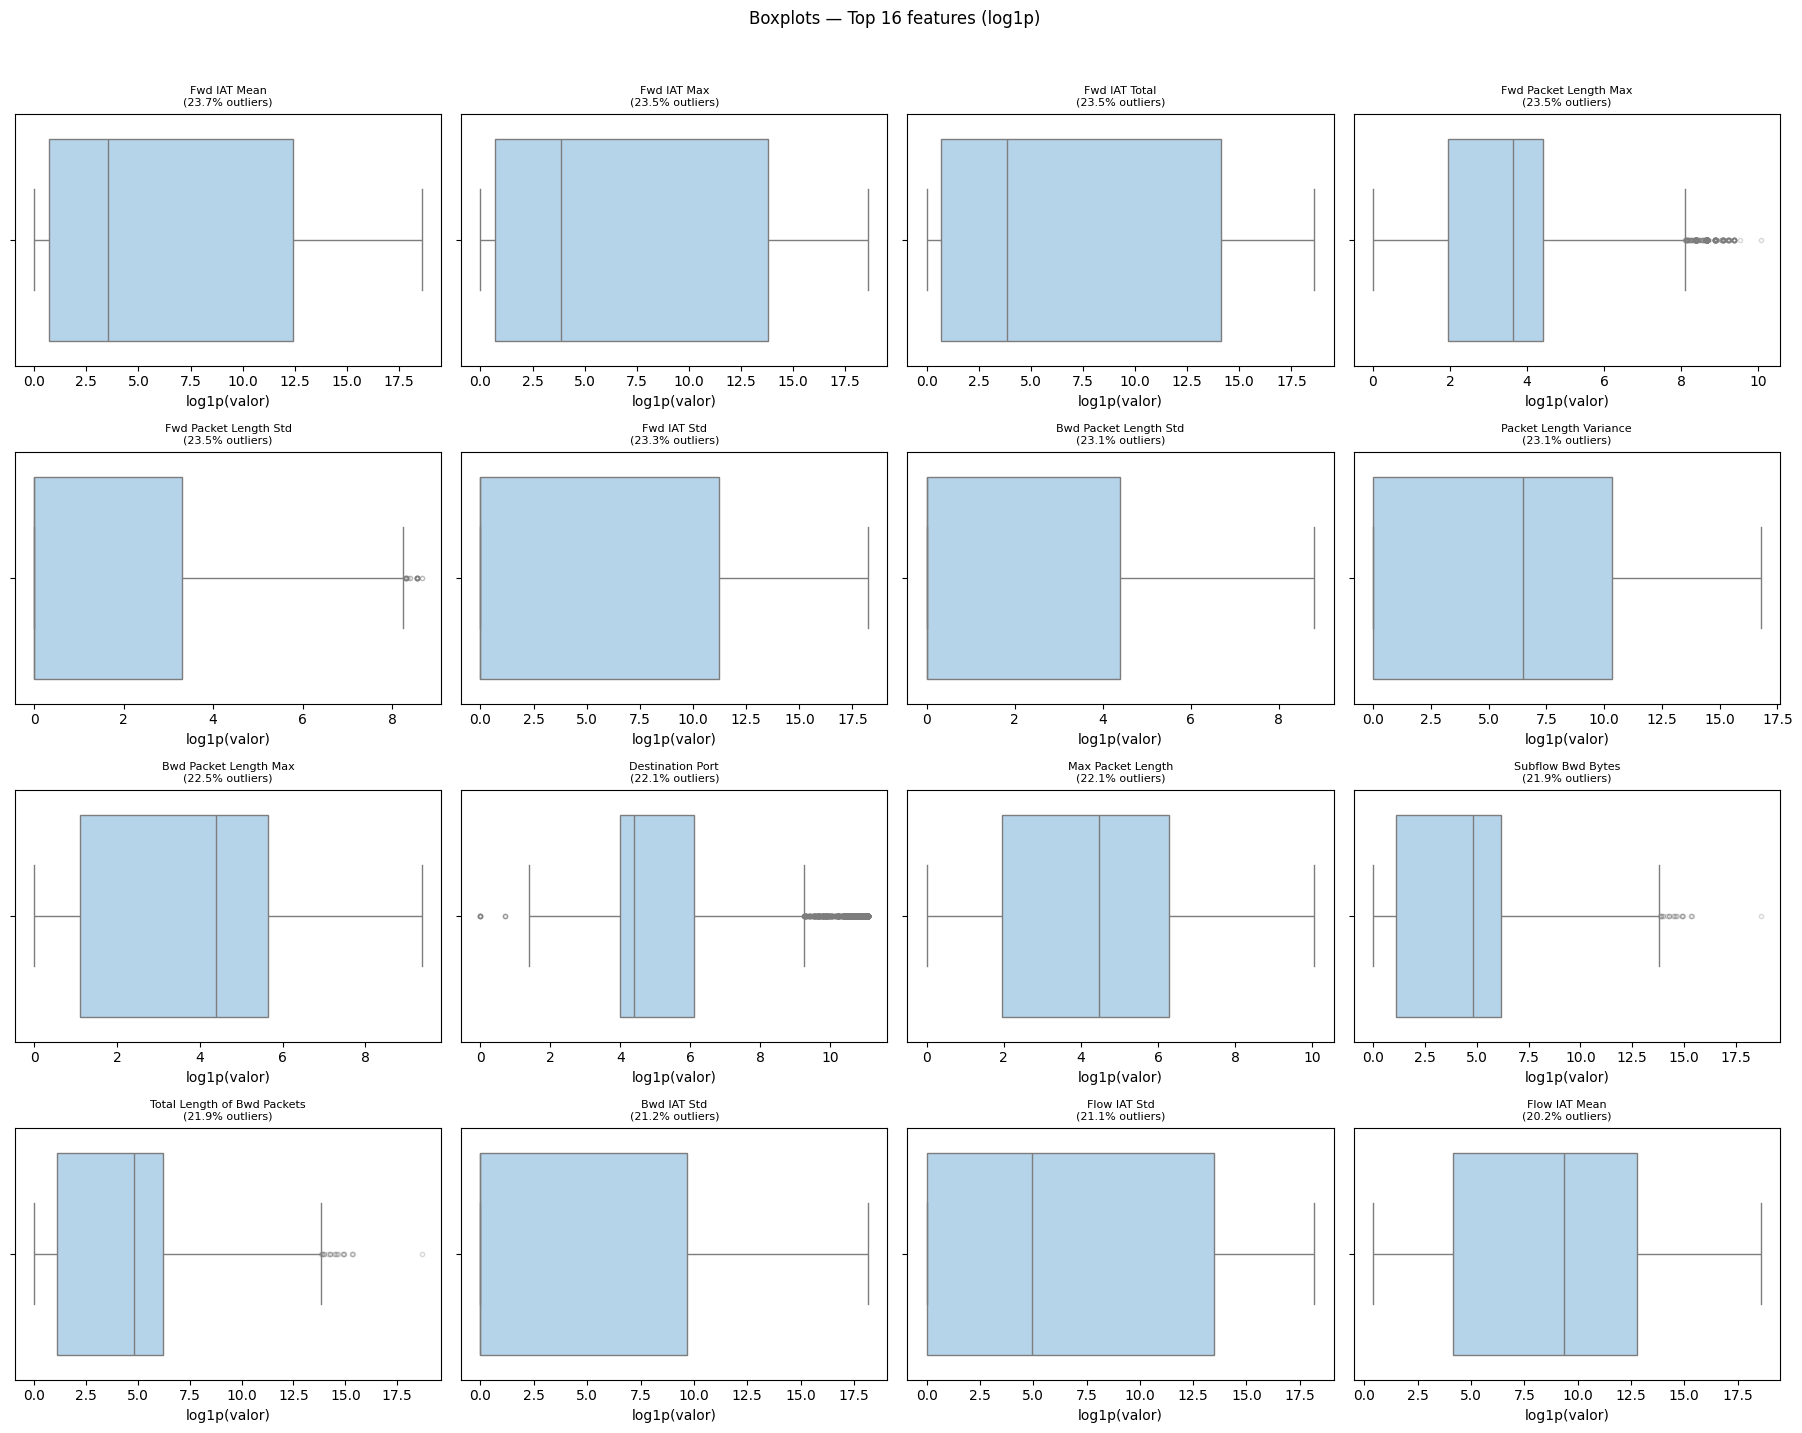

In [ ]:
# Visualizamos las 16 con mayor proporción de outliers

# Preparación compacta de datos
cols = outliers_df.head(16).index.tolist()
muestra = df[num_cols].sample(min(30000, len(df)), random_state=42).apply(np.log1p)

# Configuración del gráfico con Seaborn
plt.figure(figsize=(18, 14))
for i, col in enumerate(cols):
    ax = plt.subplot(4, 4, i + 1)
    sns.boxplot(data=muestra[col], orient='h', color=COLOR_NEUTRO,
                flierprops={'marker': '.', 'alpha': 0.3})

    ax.set_title(f"{col}\n({outliers_pct[col]:.1f}% outliers)", fontsize=8)
    ax.set(xlabel='log1p(valor)')

plt.suptitle('Boxplots — Top 16 features (log1p)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Qué son los outliers en este contexto?**
Son flujos de red con valores extremadamente altos o bajos en alguna métrica. En redes, esto no es necesariamente un error ya que un ataque DoS genera millones de paquetes por segundo deliberadamente.

**¿Cuántas features tienen outliers significativos?**
La mayoría de las 78 variables presentan outliers, con varias superando el 20 % de sus valores fuera del rango esperado.

**¿Los eliminamos?**
No, los outliers son **información valiosa**, no ruido. Eliminarlos podría borrar justamente los patrones que distinguen un ataque del tráfico normal.

# 3. Limpieza y Calidad del Dataset

## 3.1 Análisis de variables con comportamiento anómalo

In [11]:
# Features constantes (varianza cero)
# Si una columna tiene el mismo valor en todas las filas, no aporta nada al modelo
rango = df[num_cols].max() - df[num_cols].min()
constantes = rango[rango == 0].index.tolist()

print(f'Features constantes encontradas: {len(constantes)}')
for col in constantes:
    print(f'  {col}: valor único = {df[col].unique()[0]}')

Features constantes encontradas: 8
  Bwd PSH Flags: valor único = 0
  Bwd URG Flags: valor único = 0
  Fwd Avg Bytes/Bulk: valor único = 0
  Fwd Avg Packets/Bulk: valor único = 0
  Fwd Avg Bulk Rate: valor único = 0
  Bwd Avg Bytes/Bulk: valor único = 0
  Bwd Avg Packets/Bulk: valor único = 0
  Bwd Avg Bulk Rate: valor único = 0


In [13]:
# Features con alta proporción de ceros (>50 %)
pct_ceros = (df[num_cols] == 0).mean() * 100
muchos_ceros   = pct_ceros[pct_ceros > 50].sort_values(ascending=False)

print(f'Features con > 50 % de ceros: {len(muchos_ceros)}')
print(muchos_ceros.to_string())

Features con > 50 % de ceros: 31
Bwd PSH Flags           100.00
Bwd URG Flags           100.00
Bwd Avg Packets/Bulk    100.00
Fwd Avg Bulk Rate       100.00
Bwd Avg Bytes/Bulk      100.00
Fwd Avg Bytes/Bulk      100.00
Fwd Avg Packets/Bulk    100.00
Bwd Avg Bulk Rate       100.00
CWE Flag Count           99.99
Fwd URG Flags            99.99
RST Flag Count           99.98
ECE Flag Count           99.98
FIN Flag Count           96.46
Fwd PSH Flags            95.36
SYN Flag Count           95.36
Active Std               92.74
Idle Std                 91.90
URG Flag Count           90.52
Active Max               80.26
Active Min               80.26
Active Mean              80.26
Idle Max                 79.96
Idle Mean                79.96
Idle Min                 79.96
Bwd Packet Length Std    71.59
Bwd IAT Std              71.33
PSH Flag Count           70.19
ACK Flag Count           68.42
Fwd Packet Length Std    65.38
Fwd IAT Std              62.75
Bwd Packet Length Min    50.79


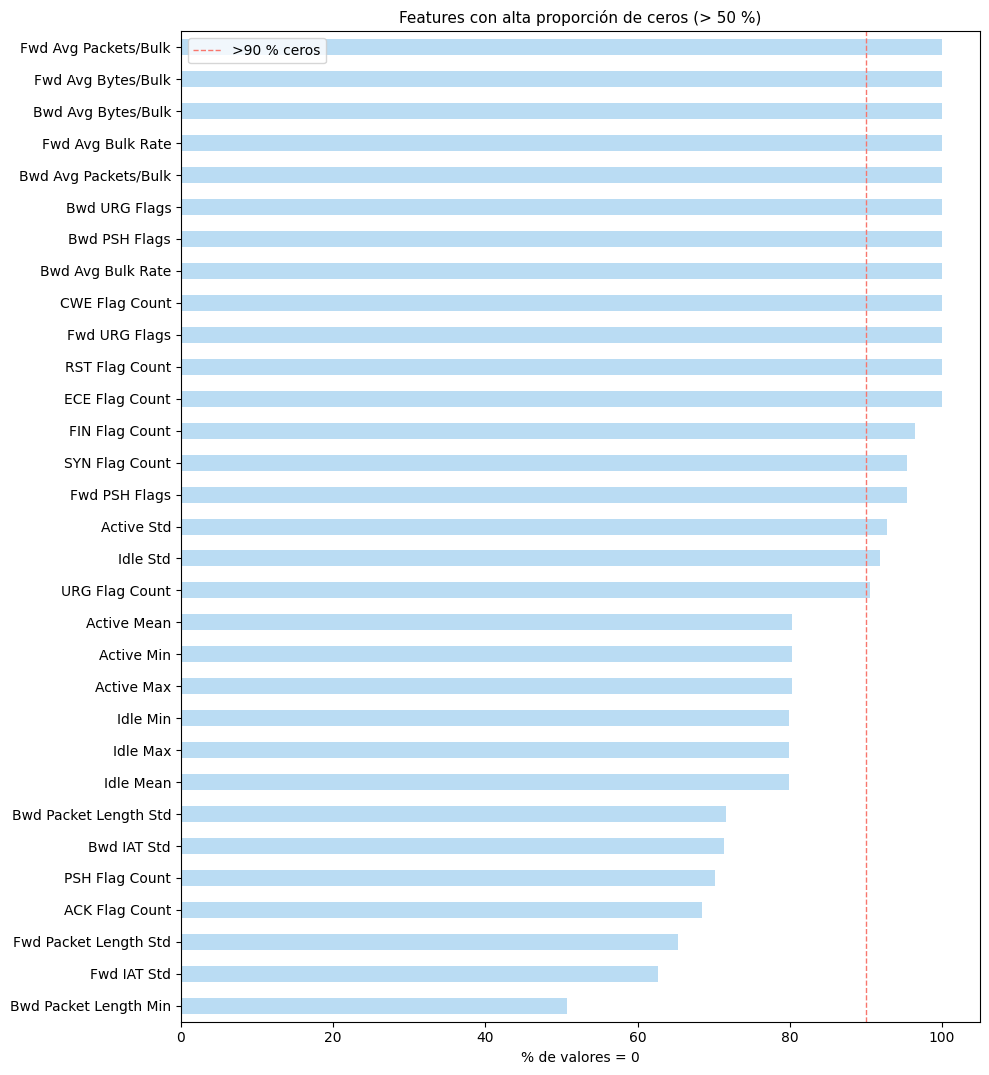

In [14]:
# Visualización
if not muchos_ceros.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(muchos_ceros) * 0.35)))
    muchos_ceros.sort_values().plot(kind='barh', ax=ax, color=COLOR_NEUTRO, alpha=0.85)
    ax.axvline(x=90, color=COLOR_ATAQUE, linestyle='--', linewidth=1, label='>90 % ceros')
    ax.set_xlabel('% de valores = 0')
    ax.set_title('Features con alta proporción de ceros (> 50 %)', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/grafico_features_con_ceros.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
# Features con valores negativos inesperados
# En tráfico de red: duración, bytes y paquetes nunca deben ser negativos

negativos = {}
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        negativos[col] = {'n_negativos': n_neg, 'valor_min': df[col].min()}

print('Features con valores negativos:')
if negativos:
    print(pd.DataFrame(negativos).T.to_string())
    print('\nVerificar si son errores de medición.')
else:
    print('Ninguna feature tiene valores negativos.')

Features con valores negativos:
                         n_negativos       valor_min
Flow Duration                 115.00          -13.00
Flow Bytes/s                   85.00   -261000000.00
Flow Packets/s                115.00     -2000000.00
Flow IAT Mean                 115.00          -13.00
Flow IAT Max                  115.00          -13.00
Flow IAT Min                 2891.00          -14.00
Fwd IAT Min                    17.00          -12.00
Fwd Header Length              35.00 -32212234632.00
Bwd Header Length              22.00  -1073741320.00
Fwd Header Length.1            35.00 -32212234632.00
Init_Win_bytes_forward    1001189.00           -1.00
Init_Win_bytes_backward   1441552.00           -1.00
min_seg_size_forward           35.00   -536870661.00

Verificar si son errores de medición.


In [17]:
# Pares de Features idénticas
# Si dos columnas tienen exactamente los mismos valores, una es redundante

print('Buscando columnas con contenido idéntico...')

hashes_cols = {}
duplicados_encontrados = []

for col in num_cols:
    # Usamos el hash de los bytes del array para comparación rápida
    h = hash(df[col].values.tobytes())
    if h in hashes_cols:
        duplicados_encontrados.append((hashes_cols[h], col))
        print(f'Idénticas: "{hashes_cols[h]}"  ==  "{col}"')
    else:
        hashes_cols[h] = col

if not duplicados_encontrados:
    print('No se encontraron columnas con valores exactamente iguales.')

Buscando columnas con contenido idéntico...
Idénticas: "Bwd PSH Flags"  ==  "Bwd URG Flags"
Idénticas: "Fwd PSH Flags"  ==  "SYN Flag Count"
Idénticas: "Fwd URG Flags"  ==  "CWE Flag Count"
Idénticas: "Fwd Header Length"  ==  "Fwd Header Length.1"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Bytes/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Packets/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Bulk Rate"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Bytes/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Packets/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Bulk Rate"
Idénticas: "Total Fwd Packets"  ==  "Subflow Fwd Packets"
Idénticas: "Total Backward Packets"  ==  "Subflow Bwd Packets"


**Conclusiones del Análisis**

Tenemos los siguientes problemas críticos que afectan la calidad de los datos para el entrenamiento de un modelo:

* **Redundancia Absoluta (Varianza Cero)**: Existen 8 columnas constantes (como Bwd PSH Flags y Fwd Avg Bulk Rate) que contienen el mismo valor ($0$) en todas las filas.  
* **Altísima Proporción de Ceros**: Existen 31 variables donde más del 50% de los datos son ceros, llegando incluso al 100% en varios casos.
* **Inconsistencias Físicas (Valores Negativos)**: Existen valores negativos en variables donde no debería, como Flow Duration (duración), Flow Bytes/s y Header Length, esto sugiere errores de medición.  
* **Duplicidad de Información**: Existen varias columnas idénticas entre sí, como Fwd PSH Flags y SYN Flag Count, o las versiones duplicadas de Fwd Header Length.

**DECISIÓN**: Realizar una limpieza de columnas.

1. Eliminar Columnas Constantes
2. Columnas Duplicadas: vamos a quedarnos con una sola versión de los pares idénticos.
3. Variables con Valores Negativos Críticos:
    * Si los valores negativos son pocos, eliminarmos solo esas filas o reemplazarlos por el valor absoluto/mediana.
    * Si una columna tiene valores negativos muy extremos (como Fwd Header Length con $-32,212,234,632.00$), es mejor descartar la columna, ya que el dato es erroneo.

## 3.2 Limpieza y Calidad del Dataset

In [ ]:
# Definir columnas a eliminar por categorías
cols_constantes = constantes  # Las 8 identificadas con rango cero
cols_duplicadas = [
    'Fwd Header Length.1',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'SYN Flag Count',
    'CWE Flag Count'
]
# Eliminamos las que tienen errores de medición graves
cols_corruptas = ['Fwd Header Length', 'Bwd Header Length']

# Consolidar lista total de eliminación (sin duplicar nombres)
to_drop = list(set(cols_constantes + cols_duplicadas + cols_corruptas))

# Ejecutar la eliminación
df_clean = df.drop(columns=to_drop)

# Reporte de cambios
print(f"Limpieza completada.")
print(f"  - Columnas originales: {df.shape[1]}")
print(f"  - Columnas eliminadas: {len(to_drop)}")
print(f"  - Columnas restantes:  {df_clean.shape[1]}")
print(f"\nVariables eliminadas: {sorted(to_drop)}")

# Actualizar num_cols para futuros análisis
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

Limpieza completada.
  - Columnas originales: 79
  - Columnas eliminadas: 15
  - Columnas restantes:  64

Variables eliminadas: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Header Length', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Header Length', 'Fwd Header Length.1', 'SYN Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Packets']


In [ ]:
# CHECKPOINT: DATASET LIMPIO Y METADATOS
ruta_parquet = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'
ruta_meta = f'{CHECKPOINT_DIR}/metadatos_limpieza.txt'

# Guardar Dataset
df_clean.to_parquet(ruta_parquet, index=False)

# Guardar Metadatos de la sesión
with open(ruta_meta, 'w') as f:
    f.write(f"Fecha: {datetime.datetime.now()}\n")
    f.write(f"Columnas finales: {df_clean.shape[1]}\n")
    f.write(f"Filas finales: {df_clean.shape[0]:,}\n")
    f.write(f"Variables eliminadas: {len(to_drop)}\n")
    f.write(f"Target balance (BENIGN %): {(df_clean['Label'] == 'BENIGN').mean()*100:.2f}%")

# Verificación
df_verify = pd.read_parquet(ruta_parquet)
print(f'Dataset guardado: {ruta_parquet}')
print(f'   Dimensiones    : {df_verify.shape[0]:,} filas × {df_verify.shape[1]} columnas')
print(f'   Tamaño disco   : {os.path.getsize(ruta_parquet) / 1024**2:.1f} MB')
print(f'   Metadatos en   : {ruta_meta}')

Dataset guardado: /content/drive/MyDrive/Colab Notebooks/Checkpoints/dataset_checkpoint_sec3.parquet
   Dimensiones    : 2,827,876 filas × 64 columnas
   Tamaño disco   : 308.7 MB
   Metadatos en   : /content/drive/MyDrive/Colab Notebooks/Checkpoints/metadatos_limpieza.txt
